# 260413-1: Numpy로 Backpropagation 직접 구현하기

이번 실습에서는 **numpy**를 사용하여 신경망의 핵심인 **역전파(Backpropagation)**를 직접 구현합니다.
PyTorch의 `autograd`가 내부에서 수행하는 연산을 하나씩 직접 만들어보며 원리를 직접 확인합니다.

## 학습 목표
- **Computational Graph**와 **Gate Operations** 이해하기
- **모듈형 레이어** 설계 패턴 (forward/backward + cache) 이해하기
- Affine, ReLU, Softmax Loss 각각의 forward/backward 구현하기
- 모듈을 조립하여 **2-Layer Network** 전체 학습 파이프라인 구현하기
- **Gradient Checking**으로 구현 검증하기
- 레이어별 **Gradient Flow** 시각화하기

## 구성
1. Computational Graph & Gate Operations
2. 모듈형 레이어 설계 패턴
3. Affine Layer (Forward & Backward)
4. ReLU Layer (Forward & Backward)
5. Softmax Loss
6. 2-Layer Network 조립 & 학습
7. Gradient Flow 분석


### Recap: 핵심 개념

> **MLP (Multilayer Perceptron)** — Forward & Backward Propagation

| 개념 | 핵심 |
|------|------|
| **MLP 구조** | Input → Hidden layers (Affine + Activation) → Output → Loss |
| **Forward Signal** | 입력 $x$를 순방향으로 통과시켜 예측값 $\hat{y}$ 생성 |
| **Backward Signal** | Loss에서 시작하여 역방향으로 각 파라미터의 gradient 계산 |
| **Chain Rule** | $\frac{\partial L}{\partial w} = \frac{\partial L}{\partial \text{out}} \cdot \frac{\partial \text{out}}{\partial z} \cdot \frac{\partial z}{\partial w}$ |
| **Gate Operations** | Adder: gradient 분배 / Multiplier: 입력값 교환 / Fanout: gradient 합산 |
| **Vanishing Gradient** | Sigmoid gradient가 최대 0.25 → 층이 깊으면 gradient가 기하급수적으로 감소 |

이번 실습에서는 **각 gate/layer의 forward & backward를 직접 numpy로 구현**합니다.


In [1]:
# Colab environment setup
import sys

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    import subprocess
    gpu_info = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
    if gpu_info.returncode == 0:
        print('GPU available:')
        print(gpu_info.stdout.split('\n')[8])
    else:
        print('No GPU detected (not needed for this numpy lab)')
    print('Colab detected. Ready!')
else:
    print('Running locally')

GPU available:
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
Colab detected. Ready!


In [2]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.figsize'] = (12.0, 6.0)
plt.rcParams['image.interpolation'] = 'nearest'

def rel_error(x, y):
    """Returns relative error between two arrays."""
    return np.max(np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y))))

def eval_numerical_gradient_array(f, x, df, h=1e-5):
    """Numeric gradient for array-valued function."""
    grad = np.zeros_like(x)
    it = np.nditer(x, flags=['multi_index'], op_flags=['readwrite'])
    while not it.finished:
        ix = it.multi_index
        oldval = x[ix]
        x[ix] = oldval + h
        pos = f(x).copy()
        x[ix] = oldval - h
        neg = f(x).copy()
        x[ix] = oldval
        grad[ix] = np.sum((pos - neg) * df) / (2 * h)
        it.iternext()
    return grad

print('Utilities loaded.')

Utilities loaded.


## 1. Computational Graph & Gate Operations

### Computational Graph

신경망의 연산을 **그래프**로 표현하면 역전파를 체계적으로 이해할 수 있습니다.

```
                    Forward →
 ┌───────┐    ┌────────┐    ┌──────┐    ┌────────┐    ┌──────────┐
 │ Input  │───→│Affine_1│───→│ ReLU │───→│Affine_2│───→│ Softmax  │───→ Loss
 │  x     │    │ W1, b1 │    │      │    │ W2, b2 │    │  Loss    │
 └───────┘    └────────┘    └──────┘    └────────┘    └──────────┘
                    ← Backward
```

**Forward pass**: 입력 → 출력 방향으로 값을 계산하며, 각 노드에서 **cache** 저장
**Backward pass**: 출력 → 입력 방향으로 gradient를 전파하며, cache를 활용

### Gate Operations

모든 연산은 기본적인 **gate** 들의 조합입니다:

```
 Adder Gate          Multiplier Gate         Fanout
 ──────────          ───────────────         ──────
 a ──→ ┌───┐           a ──→ ┌───┐             a ──→ ┌───┐──→ branch 1
          │   +  │──→  c           │  ×  │──→ c              │      │
 b ──→ └───┘           b ──→ └───┘                      └───┘──→ branch 2

 Forward:            Forward:                Forward:
 c = a + b           c = a × b               두 곳으로 복사

 Backward:           Backward:               Backward:
 ∂c/∂a = 1          ∂c/∂a = b               da = d(branch1) + d(branch2)
 ∂c/∂b = 1          ∂c/∂b = a               (gradient를 합산)
 (gradient 분배)     (gradient 교환)
```

아래에서 실제 숫자로 확인해봅니다.


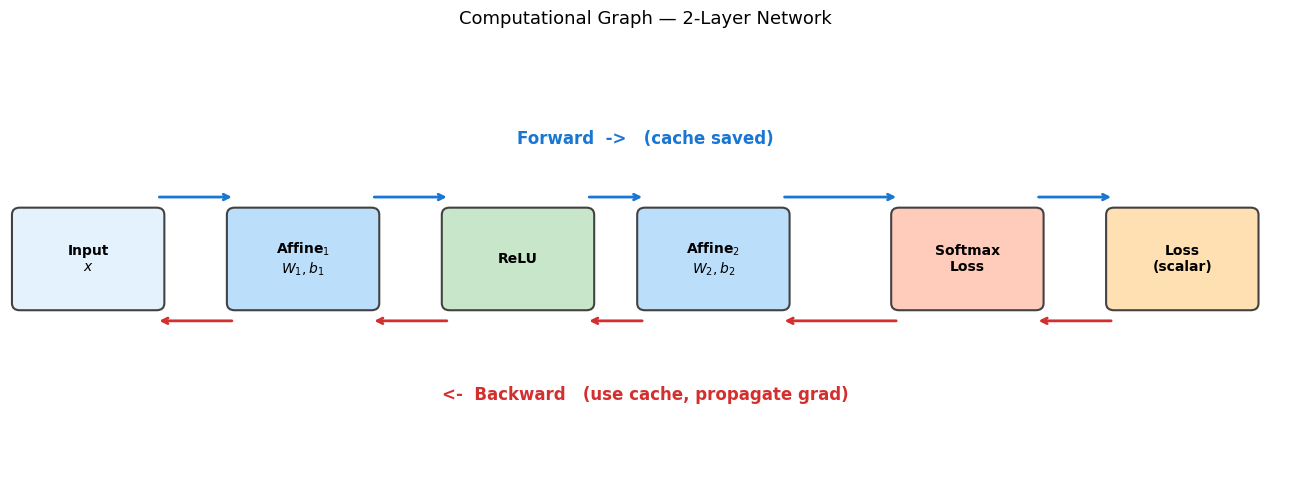

In [3]:
# Computational Graph visualization (제공 — 실행만 하세요)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(13, 5))
ax.set_xlim(0, 13); ax.set_ylim(0, 5); ax.axis('off')

nodes = [('Input\n$x$', 0.8, '#E3F2FD'),
         ('Affine$_1$\n$W_1, b_1$', 3.0, '#BBDEFB'),
         ('ReLU', 5.2, '#C8E6C9'),
         ('Affine$_2$\n$W_2, b_2$', 7.2, '#BBDEFB'),
         ('Softmax\nLoss', 9.8, '#FFCCBC'),
         ('Loss\n(scalar)', 12.0, '#FFE0B2')]

for label, x, color in nodes:
    box = FancyBboxPatch((x-0.7, 2.0), 1.4, 1.0, boxstyle='round,pad=0.08',
                         facecolor=color, edgecolor='#424242', linewidth=1.5)
    ax.add_patch(box)
    ax.text(x, 2.5, label, ha='center', va='center', fontsize=10, fontweight='bold')

# Forward arrows (top)
for i in range(len(nodes)-1):
    x0 = nodes[i][1] + 0.7; x1 = nodes[i+1][1] - 0.7
    ax.annotate('', xy=(x1, 3.2), xytext=(x0, 3.2),
                arrowprops=dict(arrowstyle='->', color='#1976D2', lw=2))
ax.text(6.5, 3.8, 'Forward  ->   (cache saved)', ha='center', fontsize=12,
        color='#1976D2', fontweight='bold')

# Backward arrows (bottom)
for i in range(len(nodes)-1, 0, -1):
    x0 = nodes[i][1] - 0.7; x1 = nodes[i-1][1] + 0.7
    ax.annotate('', xy=(x1, 1.8), xytext=(x0, 1.8),
                arrowprops=dict(arrowstyle='->', color='#D32F2F', lw=2))
ax.text(6.5, 0.9, '<-  Backward   (use cache, propagate grad)', ha='center',
        fontsize=12, color='#D32F2F', fontweight='bold')

plt.title('Computational Graph — 2-Layer Network', fontsize=13, pad=10)
plt.tight_layout(); plt.show()


In [4]:
# Gate Operations Demo: forward -> backward with actual numbers

# === Adder Gate: c = a + b ===
a, b = 3.0, -2.0
c = a + b  # forward: c = 1.0

# backward: dc/da = 1, dc/db = 1
dc = 1.0  # upstream gradient (assume dL/dc = 1)
da = dc * 1.0  # = 1.0
db = dc * 1.0  # = 1.0

print("=== Adder Gate: c = a + b ===")
print(f"  Forward:  a={a}, b={b} -> c={c}")
print(f"  Backward: dc={dc} -> da={da}, db={db}  (gradient distributed equally)")

# === Multiplier Gate: c = a * b ===
a, b = 3.0, -2.0
c = a * b  # forward: c = -6.0

dc = 1.0
da = dc * b  # = -2.0 (swapped!)
db = dc * a  # = 3.0  (swapped!)

print("\n=== Multiplier Gate: c = a * b ===")
print(f"  Forward:  a={a}, b={b} -> c={c}")
print(f"  Backward: dc={dc} -> da={da} (=b), db={db} (=a)  (values swapped!)")

# === Neuron Example: out = sigmoid(w*x + b) ===
w, x, b_val = 2.0, -1.0, 3.0
z = w * x + b_val   # = 1.0
out = 1.0 / (1.0 + np.exp(-z))  # sigmoid(1.0) ≈ 0.731

dout = 1.0
dsigmoid = out * (1 - out)  # sigmoid local gradient
dz = dout * dsigmoid         # ≈ 0.197
dw = dz * x                  # ≈ -0.197
dx = dz * w                  # ≈ 0.393
db_grad = dz * 1.0           # ≈ 0.197

print("\n=== Neuron: out = sigmoid(w*x + b) ===")
print(f"  Forward:  w={w}, x={x}, b={b_val}")
print(f"            z = w*x + b = {z}")
print(f"            out = sigmoid(z) = {out:.4f}")
print(f"  Backward: dout={dout}")
print(f"            dsigmoid = out*(1-out) = {dsigmoid:.4f}")
print(f"            dz = {dz:.4f}")
print(f"            dw = dz*x = {dw:.4f}")
print(f"            dx = dz*w = {dx:.4f}")
print(f"            db = dz*1 = {db_grad:.4f}")

=== Adder Gate: c = a + b ===
  Forward:  a=3.0, b=-2.0 -> c=1.0
  Backward: dc=1.0 -> da=1.0, db=1.0  (gradient distributed equally)

=== Multiplier Gate: c = a * b ===
  Forward:  a=3.0, b=-2.0 -> c=-6.0
  Backward: dc=1.0 -> da=-2.0 (=b), db=3.0 (=a)  (values swapped!)

=== Neuron: out = sigmoid(w*x + b) ===
  Forward:  w=2.0, x=-1.0, b=3.0
            z = w*x + b = 1.0
            out = sigmoid(z) = 0.7311
  Backward: dout=1.0
            dsigmoid = out*(1-out) = 0.1966
            dz = 0.1966
            dw = dz*x = -0.1966
            dx = dz*w = 0.3932
            db = dz*1 = 0.1966


## 2. 모듈형 레이어 설계 패턴

신경망을 **독립적인 모듈**로 나누면 레고 블록처럼 조립할 수 있습니다.

```
┌──────────── Layer Module ────────────┐
│                                      │
│  Forward:   x, w, b  ──→  out       │
│             (입력)     ↓   (출력)     │
│                      cache           │
│                       ↓              │
│  Backward:  dout, cache ──→ dx,dw,db │
│             (upstream)     (local)    │
│                                      │
└──────────────────────────────────────┘
```

| 구성 요소 | 역할 |
|-----------|------|
| **forward(x, w, b)** | 입력 → 출력 계산, backward에 필요한 값을 **cache**에 저장 |
| **backward(dout, cache)** | upstream gradient + cache → 입력/파라미터 gradient 계산 |
| **cache** | forward에서 저장, backward에서 사용. 중간 계산을 다시 할 필요 없음 |

> **이 패턴이 PyTorch `autograd`의 내부 동작 원리**입니다. 260413-2에서 이를 자동화합니다.


/tmp/ipykernel_6836/150242218.py:38: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_6836/150242218.py:38: UserWarning: Glyph 47484 (\N{HANGUL SYLLABLE REUL}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_6836/150242218.py:38: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_6836/150242218.py:38: UserWarning: Glyph 54616 (\N{HANGUL SYLLABLE HA}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_6836/150242218.py:38: UserWarning: Glyph 47140 (\N{HANGUL SYLLABLE RYEO}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_6836/150242218.py:38: UserWarning: Glyph 47732 (\N{HANGUL SYLLABLE MYEON}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_6836/150242218.py:38: Us

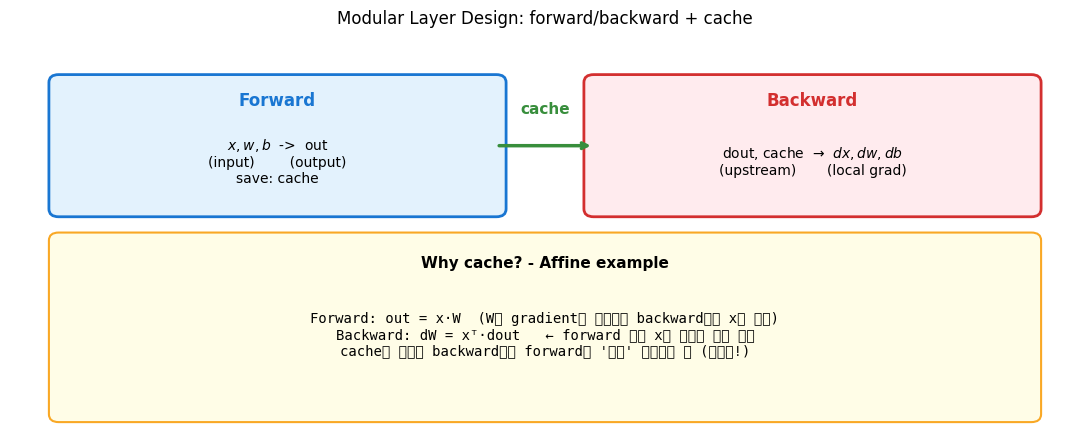


[ Cache necessity numeric demo ]
Forward:  x=[2. 3.], W=
[[ 1.  -1. ]
 [ 0.5  2. ]]
          out = x·W = [3.5 4. ]

Backward with cached x:  dW = xᵀ·dout = 
[[2. 2.]
 [3. 3.]]
-> cache stored x, so dW can be computed immediately in backward
-> without cache, we would need to re-run forward to recover x


In [5]:
# Modular Layer Pattern + cache 예시 (제공 — 실행만 하세요)
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.set_xlim(0, 11); ax.set_ylim(0, 5); ax.axis('off')

# Forward block
ax.add_patch(FancyBboxPatch((0.5, 2.8), 4.5, 1.6, boxstyle='round,pad=0.1',
                             facecolor='#E3F2FD', edgecolor='#1976D2', lw=2))
ax.text(2.75, 4.1, 'Forward', ha='center', fontsize=12, fontweight='bold', color='#1976D2')
ax.text(2.75, 3.4, '$x, w, b$  ->  out\n(input)        (output)\nsave: cache',
        ha='center', va='center', fontsize=10)

# Backward block
ax.add_patch(FancyBboxPatch((6.0, 2.8), 4.5, 1.6, boxstyle='round,pad=0.1',
                             facecolor='#FFEBEE', edgecolor='#D32F2F', lw=2))
ax.text(8.25, 4.1, 'Backward', ha='center', fontsize=12, fontweight='bold', color='#D32F2F')
ax.text(8.25, 3.4, 'dout, cache  →  $dx, dw, db$\n(upstream)       (local grad)',
        ha='center', va='center', fontsize=10)

# cache arrow
ax.annotate('', xy=(6.0, 3.6), xytext=(5.0, 3.6),
            arrowprops=dict(arrowstyle='->', color='#388E3C', lw=2.5))
ax.text(5.5, 4.0, 'cache', ha='center', fontsize=11, color='#388E3C', fontweight='bold')

# Cache example text box
ax.add_patch(FancyBboxPatch((0.5, 0.2), 10.0, 2.2, boxstyle='round,pad=0.1',
                             facecolor='#FFFDE7', edgecolor='#F9A825', lw=1.5))
ax.text(5.5, 2.05, 'Why cache? - Affine example', ha='center', fontsize=11, fontweight='bold')
ax.text(5.5, 1.2,
    "Forward: out = x·W  (W의 gradient를 구하려면 backward에서 x가 필요)\n"
    "Backward: dW = xᵀ·dout   ← forward 때의 x가 있어야 계산 가능\n"
    "cache가 없으면 backward에서 forward를 '다시' 실행해야 함 (비효율!)",
    ha='center', va='center', fontsize=10, family='monospace')

plt.title('Modular Layer Design: forward/backward + cache', fontsize=12, pad=8)
plt.tight_layout(); plt.show()

# 숫자로 확인: cache가 없다면?
print("\n[ Cache necessity numeric demo ]")
import numpy as np
x = np.array([[2.0, 3.0]])
W = np.array([[1.0, -1.0], [0.5, 2.0]])
out = x @ W
print(f"Forward:  x={x.ravel()}, W=\n{W}")
print(f"          out = x·W = {out.ravel()}")

# Backward: dW를 구하려면 x가 필요
dout = np.array([[1.0, 1.0]])  # upstream
dW_with_cache = x.T @ dout
print(f"\nBackward with cached x:  dW = xᵀ·dout = \n{dW_with_cache}")
print("-> cache stored x, so dW can be computed immediately in backward")
print("-> without cache, we would need to re-run forward to recover x")


## 3. Affine Layer

### 3-1. Forward Pass

**Affine (fully-connected) 레이어**는 입력에 가중치를 곱하고 편향을 더합니다:

$$\text{out} = X_{\text{flat}} \cdot W + b$$

입력 `x`의 shape이 `(N, d_1, ..., d_k)`일 때, 먼저 `(N, D)`로 펼친 후(D = d_1 × ... × d_k) 행렬곱을 수행합니다.

```
x: (N, d1, d2, ..., dk)  ──reshape──→  x_flat: (N, D)  ──matmul──→  out: (N, M)
                                                    W: (D, M)
                                                    b: (M,)
```


In [6]:
def affine_forward(x, w, b):
    """
    Affine (fully-connected) 레이어의 forward pass를 구현하세요.

    Args:
        x: 입력 데이터, shape (N, d_1, ..., d_k)
        w: 가중치, shape (D, M) where D = d_1 * ... * d_k
        b: 편향, shape (M,)
    Returns:
        out: 출력, shape (N, M)
        cache: backward pass에 필요한 값들의 tuple

    Hint: x.reshape(N, -1)으로 2D로 펼친 후 행렬곱을 수행하세요.
    """
    ############################################################################
    # TODO 1: Affine forward pass를 구현하세요 (~3줄)                             #
    ############################################################################
    N = x.shape[0]
    x_flat = x.reshape(N, -1)
    out = x_flat @ w + b
    #                             END OF YOUR CODE                             #
    ############################################################################
    cache = (x, w, b)
    return out, cache

In [7]:
# Affine forward verification
num_inputs = 2
input_shape = (4, 5, 6)
output_dim = 3

input_size = num_inputs * np.prod(input_shape)
weight_size = output_dim * np.prod(input_shape)

x = np.linspace(-0.1, 0.5, num=input_size).reshape(num_inputs, *input_shape)
w = np.linspace(-0.2, 0.3, num=weight_size).reshape(np.prod(input_shape), output_dim)
b = np.linspace(-0.3, 0.1, num=output_dim)

out, _ = affine_forward(x, w, b)
correct_out = np.array([[ 1.49834967,  1.70660132,  1.91485297],
                        [ 3.25553199,  3.5141327,   3.77273342]])

print('Testing affine_forward:')
print('Relative error:', rel_error(out, correct_out))  # should be ~1e-9

Testing affine_forward:
Relative error: 9.769848888397517e-10


### 3-2. Backward Pass

Forward에서 $\text{out} = X_{\text{flat}} W + b$이므로, chain rule에 의해:

| Gradient | 수식 | 직관 |
|----------|------|------|
| $\frac{\partial L}{\partial X_{\text{flat}}}$ | $\frac{\partial L}{\partial \text{out}} \cdot W^T$ | upstream gradient를 가중치 전치로 "역방향 투영" |
| $\frac{\partial L}{\partial W}$ | $X_{\text{flat}}^T \cdot \frac{\partial L}{\partial \text{out}}$ | 입력의 전치 × upstream (Multiplier Gate!) |
| $\frac{\partial L}{\partial b}$ | $\sum_{i=1}^{N} \frac{\partial L}{\partial \text{out}_i}$ | N개 샘플의 gradient를 합산 (Fanout!) |

> `dx`는 원래 입력 `x`와 같은 shape으로 `reshape`해야 합니다.


In [9]:
def affine_backward(dout, cache):
    """
    Affine 레이어의 backward pass를 구현하세요.

    Args:
        dout: upstream gradient, shape (N, M)
        cache: (x, w, b) from forward pass
    Returns:
        dx: gradient w.r.t. x, same shape as x
        dw: gradient w.r.t. w, shape (D, M)
        db: gradient w.r.t. b, shape (M,)

    Hint: dx를 계산한 후 원래 x의 shape으로 reshape하세요.
    """
    x, w, b = cache
    ############################################################################
    # TODO 2: Affine backward pass를 구현하세요 (~4줄)                            #
    ############################################################################
    N = x.shape[0]
    x_flat = x.reshape(N, -1)
    dx = dout @ w.T
    dx = dx.reshape(x.shape)
    dw = x_flat.T @ dout
    db = np.sum(dout, axis=0)
    #                             END OF YOUR CODE                             #
    ############################################################################
    return dx, dw, db

In [10]:
# Affine backward verification (numerical gradient check)
np.random.seed(231)
x = np.random.randn(10, 2, 3)
w = np.random.randn(6, 5)
b = np.random.randn(5)
dout = np.random.randn(10, 5)

dx_num = eval_numerical_gradient_array(lambda xx: affine_forward(xx, w, b)[0], x, dout)
dw_num = eval_numerical_gradient_array(lambda ww: affine_forward(x, ww, b)[0], w, dout)
db_num = eval_numerical_gradient_array(lambda bb: affine_forward(x, w, bb)[0], b, dout)

_, cache = affine_forward(x, w, b)
dx, dw, db = affine_backward(dout, cache)

print('Testing affine_backward:')
print('dx error:', rel_error(dx_num, dx))   # ~1e-10
print('dw error:', rel_error(dw_num, dw))   # ~1e-10
print('db error:', rel_error(db_num, db))   # ~1e-10
print('\n-> relative error ~1e-10 means analytic backward matches numerical grad')


Testing affine_backward:
dx error: 5.399100368651805e-11
dw error: 9.904211865398145e-11
db error: 2.4122867568119087e-11

-> relative error ~1e-10 means analytic backward matches numerical grad


## 4. ReLU Layer

### 4-1. Forward Pass

$$\text{ReLU}(x) = \max(0, x)$$

ReLU는 양수는 그대로 통과, 음수는 0으로 만드는 가장 간단하면서도 효과적인 활성화 함수입니다.


In [11]:
def relu_forward(x):
    """
    ReLU 활성화 함수의 forward pass를 구현하세요.

    Args:
        x: 입력, 임의의 shape
    Returns:
        out: 출력, x와 같은 shape
        cache: backward에 필요한 값

    Hint: np.maximum 함수를 사용하세요.
    """
    ############################################################################
    # TODO 3: ReLU forward pass를 구현하세요 (~1줄)                               #
    ############################################################################
    out = np.maximum(0,x)
    #                             END OF YOUR CODE                             #
    ############################################################################
    cache = x
    return out, cache

In [12]:
# ReLU forward verification
x = np.linspace(-0.5, 0.5, num=12).reshape(3, 4)
out, _ = relu_forward(x)

correct_out = np.array([[ 0.,          0.,          0.,          0.,        ],
                        [ 0.,          0.,          0.04545455,  0.13636364,],
                        [ 0.22727273,  0.31818182,  0.40909091,  0.5,       ]])

print('Testing relu_forward:')
print('Relative error:', rel_error(out, correct_out))  # ~5e-8

Testing relu_forward:
Relative error: 4.999999798022158e-08


### 4-2. Backward Pass

ReLU의 gradient는 매우 단순합니다:

$$\frac{\partial \text{ReLU}}{\partial x} = \begin{cases} 1 & \text{if } x > 0 \\ 0 & \text{otherwise} \end{cases}$$

> **직관**: Forward에서 양수였던 위치는 gradient를 그대로 통과시키고, 0이었던 위치는 gradient를 차단합니다.
> 이것이 ReLU가 **vanishing gradient를 완화**하는 이유입니다 — 양수 구간에서는 gradient가 1로 유지!


In [13]:
def relu_backward(dout, cache):
    """
    ReLU의 backward pass를 구현하세요.

    Args:
        dout: upstream gradient, 임의의 shape
        cache: forward에서 저장한 x
    Returns:
        dx: gradient w.r.t. x, dout과 같은 shape

    Hint: x > 0인 위치만 gradient를 통과시키세요.
    """
    x = cache
    ############################################################################
    # TODO 4: ReLU backward pass를 구현하세요 (~1줄)                              #
    ############################################################################
    dx = (x > 0) * dout
    #                             END OF YOUR CODE                             #
    ############################################################################
    return dx

Testing relu_backward:
dx error: 3.2756349136310288e-12


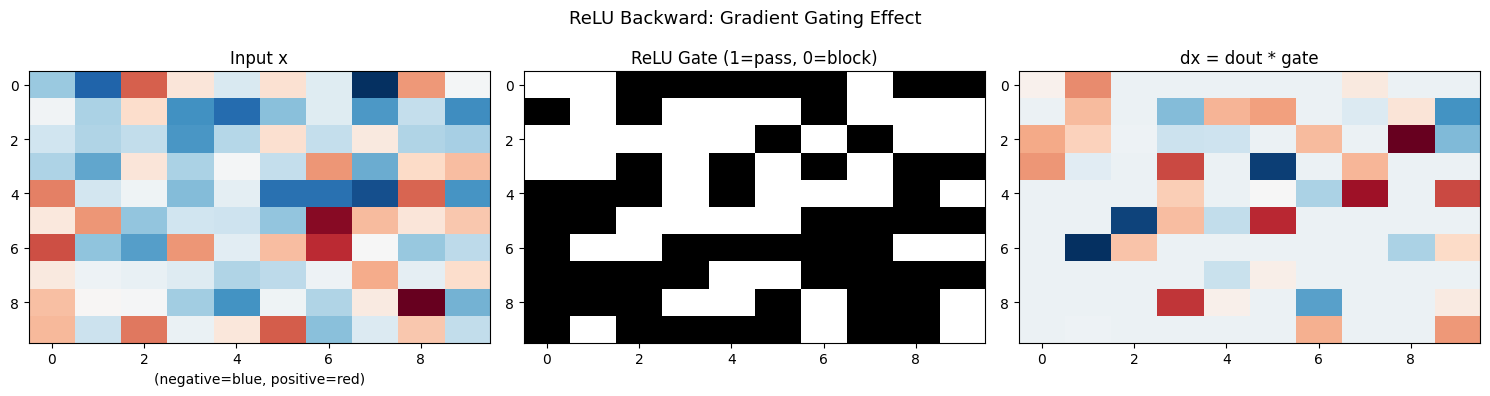


Blocked gradient ratio: 55.0% (these neurons are "dead" for this input)


In [14]:
# ReLU backward verification + gradient gate visualization
np.random.seed(231)
x = np.random.randn(10, 10)
dout = np.random.randn(*x.shape)

dx_num = eval_numerical_gradient_array(lambda xx: relu_forward(xx)[0], x, dout)
_, cache = relu_forward(x)
dx = relu_backward(dout, cache)

print('Testing relu_backward:')
print('dx error:', rel_error(dx_num, dx))  # ~3e-12

# Visualize ReLU's gating effect
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].imshow(x, cmap='RdBu', aspect='auto')
axes[0].set_title('Input x'); axes[0].set_xlabel('(negative=blue, positive=red)')

mask = (x > 0).astype(float)
axes[1].imshow(mask, cmap='gray', aspect='auto')
axes[1].set_title('ReLU Gate (1=pass, 0=block)')

axes[2].imshow(dx, cmap='RdBu', aspect='auto')
axes[2].set_title('dx = dout * gate')

plt.suptitle('ReLU Backward: Gradient Gating Effect', fontsize=13)
plt.tight_layout()
plt.show()

blocked = 100 * (1 - mask.mean())
print(f'\nBlocked gradient ratio: {blocked:.1f}% (these neurons are "dead" for this input)')

### Affine-ReLU 편의 함수

Affine과 ReLU를 순차적으로 호출하는 헬퍼 함수를 만들어두면 2-layer network 조립이 간결해집니다.

```
x ──→ [Affine] ──→ [ReLU] ──→ out
      (W, b)      cache = (fc_cache, relu_cache)
```


In [15]:
def affine_relu_forward(x, w, b):
    """Affine -> ReLU forward pass"""
    a, fc_cache = affine_forward(x, w, b)
    out, relu_cache = relu_forward(a)
    cache = (fc_cache, relu_cache)
    return out, cache

def affine_relu_backward(dout, cache):
    """Affine -> ReLU backward pass"""
    fc_cache, relu_cache = cache
    da = relu_backward(dout, relu_cache)
    dx, dw, db = affine_backward(da, fc_cache)
    return dx, dw, db

print('Affine-ReLU convenience layers defined.')

Affine-ReLU convenience layers defined.


## 5. Softmax Loss

Day 1에서 다뤘던 Cross-Entropy Loss를 이번에는 **numpy로 직접** 구현합니다.
Loss 값과 함께 scores에 대한 **gradient**도 반환해야 합니다.

### 기본 수식

Softmax:

$$p_{i,j} = \frac{e^{x_{i,j}}}{\sum_k e^{x_{i,k}}}$$

Cross-Entropy Loss (정답 클래스 $y_i$에 대해):

$$L = -\frac{1}{N} \sum_{i=1}^{N} \log p_{i, y_i}$$

### 수치 안정성: log-sum-exp trick

$\log p_{i, y_i}$를 그대로 계산하면 $e^{x_{i,j}}$에서 **overflow**가 발생할 수 있습니다 (예: $x = 1000$).
이를 피하기 위해 각 행의 최댓값 $m_i = \max_k x_{i,k}$를 빼줍니다.

**유도 (왜 max를 빼도 되는가)**

$$
\log p_{i, y_i}
= \log \frac{e^{x_{i, y_i}}}{\sum_k e^{x_{i,k}}}
= x_{i, y_i} - \log \sum_k e^{x_{i,k}}
$$

분자/분모에 $e^{-m_i}$를 곱해도 값은 같습니다:

$$
\frac{e^{x_{i, y_i}}}{\sum_k e^{x_{i,k}}}
= \frac{e^{x_{i, y_i} - m_i}}{\sum_k e^{x_{i,k} - m_i}}
$$

따라서 정리하면:

$$
\log p_{i, y_i}
= (x_{i, y_i} - m_i) - \log \sum_k e^{x_{i,k} - m_i}
$$

우변의 $e^{x_{i,k} - m_i}$는 최대 $e^0 = 1$이므로 overflow가 없습니다. 최종 loss:

$$
L = -\frac{1}{N} \sum_i \left[ (x_{i, y_i} - m_i) - \log \sum_k e^{x_{i,k} - m_i} \right]
$$

### Gradient

$$\frac{\partial L}{\partial x_{i,j}} = \frac{1}{N}\left(p_{i,j} - \mathbb{1}[j = y_i]\right)$$

여기서 $p_{i,j}$는 수치 안정 버전으로 계산한 softmax 확률입니다.


In [ ]:
# Numerical stability demo (Day 1 recap)
logits_ok = np.array([[1.0, 2.0, 3.0]])
logits_big = np.array([[1000.0, 1001.0, 1002.0]])

def naive_softmax(z):
    exp_z = np.exp(z)
    return exp_z / exp_z.sum(axis=1, keepdims=True)

def stable_softmax(z):
    shifted = z - z.max(axis=1, keepdims=True)
    exp_z = np.exp(shifted)
    return exp_z / exp_z.sum(axis=1, keepdims=True)

print("=== Small values [1, 2, 3] ===")
print(f"  Naive:  {naive_softmax(logits_ok)}")
print(f"  Stable: {stable_softmax(logits_ok)}")

print("\n=== Large values [1000, 1001, 1002] ===")
print(f"  Naive:  {naive_softmax(logits_big)}")   # may produce nan/inf!
print(f"  Stable: {stable_softmax(logits_big)}")

print("\n-> Always subtract max for numerical stability!")

In [19]:
def softmax_loss(x, y):
    """
    Softmax (Cross-Entropy) loss와 gradient를 구현하세요.

    Args:
        x: scores, shape (N, C)
        y: 정답 레이블, shape (N,). 0 <= y[i] < C
    Returns:
        loss: 스칼라 loss 값
        dx: scores에 대한 gradient, shape (N, C)

    Hint:
        1) shifted = x - np.max(x, axis=1, keepdims=True)
        2) log_probs = shifted - log(sum(exp(shifted)))
        3) loss = mean of -log_probs at correct classes
        4) dx = (softmax_probs - one_hot_labels) / N
    """
    ############################################################################
    # TODO 5: Softmax loss와 gradient를 구현하세요 (~8줄)                         #
    ############################################################################
    shifted_logits = x - np.max(x, axis=1, keepdims=True)
    Z = np.sum(np.exp(shifted_logits), axis=1, keepdims=True)
    log_probs = shifted_logits - np.log(Z)
    probs = np.exp(log_probs)
    N = x.shape[0]
    loss = -np.sum(log_probs[np.arange(N), y]) / N
    dx = probs.copy()
    dx[np.arange(N), y] -= 1
    dx /= N

    #                             END OF YOUR CODE                             #
    ############################################################################
    return loss, dx

In [20]:
# Softmax loss verification
np.random.seed(231)
num_classes, num_inputs = 10, 50
x = 0.001 * np.random.randn(num_inputs, num_classes)
y = np.random.randint(num_classes, size=num_inputs)

loss, dx = softmax_loss(x, y)
print('Testing softmax_loss:')
print('Loss: %.4f (expected: ~%.4f)' % (loss, -np.log(1.0 / num_classes)))

# Gradient check
dx_num = np.zeros_like(x)
h = 1e-5
it = np.nditer(x, flags=['multi_index'], op_flags=['readwrite'])
while not it.finished:
    ix = it.multi_index
    oldval = x[ix]
    x[ix] = oldval + h
    loss_p, _ = softmax_loss(x, y)
    x[ix] = oldval - h
    loss_m, _ = softmax_loss(x, y)
    x[ix] = oldval
    dx_num[ix] = (loss_p - loss_m) / (2 * h)
    it.iternext()

print('dx error:', rel_error(dx_num, dx))  # should be < 1e-7

Testing softmax_loss:
Loss: 2.3025 (expected: ~2.3026)
dx error: 9.384673161989355e-09


## 6. 2-Layer Network 조립 & 학습

구현한 모듈들을 조합하여 **완전한 학습 파이프라인**을 구성합니다.

### Network Architecture
```
         Forward →
Input ──→ [Affine₁ + ReLU] ──→ [Affine₂] ──→ Softmax Loss
(N,D)      W1:(D,H) b1:(H)    W2:(H,C) b2:(C)     ↓
                                                  Loss (scalar)
         ← Backward
dX    ←── [dW1,db1,dhidden] ←── [dW2,db2,dscores] ←── dLoss
```

> Forward에서 cache를 저장 → Backward에서 **역순으로** gradient를 전파합니다.


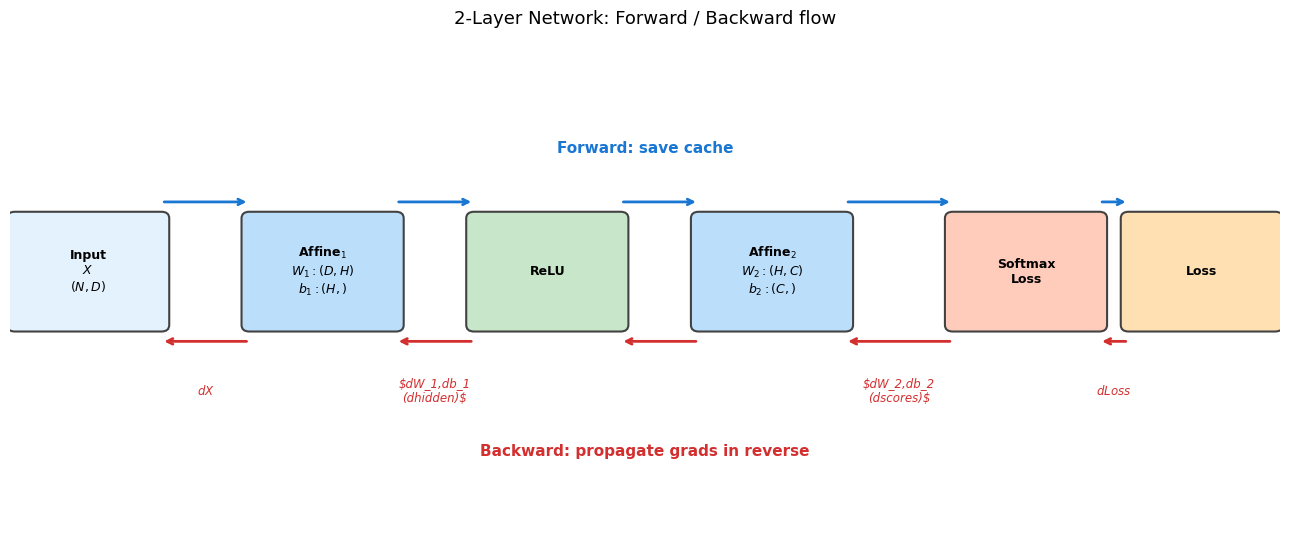

In [21]:
# 2-Layer Network 아키텍처 + gradient 흐름 (제공 — 실행만 하세요)
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.set_xlim(0, 13); ax.set_ylim(0, 6); ax.axis('off')

nodes = [
    ('Input\n$X$\n$(N, D)$', 0.8, '#E3F2FD'),
    ('Affine$_1$\n$W_1: (D,H)$\n$b_1: (H,)$', 3.2, '#BBDEFB'),
    ('ReLU', 5.5, '#C8E6C9'),
    ('Affine$_2$\n$W_2: (H,C)$\n$b_2: (C,)$', 7.8, '#BBDEFB'),
    ('Softmax\nLoss', 10.4, '#FFCCBC'),
    ('Loss', 12.2, '#FFE0B2'),
]
for label, x, color in nodes:
    box = FancyBboxPatch((x-0.75, 2.5), 1.5, 1.3, boxstyle='round,pad=0.08',
                         facecolor=color, edgecolor='#424242', lw=1.5)
    ax.add_patch(box)
    ax.text(x, 3.15, label, ha='center', va='center', fontsize=9, fontweight='bold')

# Forward
for i in range(len(nodes)-1):
    ax.annotate('', xy=(nodes[i+1][1]-0.75, 4.0), xytext=(nodes[i][1]+0.75, 4.0),
                arrowprops=dict(arrowstyle='->', color='#1976D2', lw=2))
ax.text(6.5, 4.6, 'Forward: save cache', ha='center', fontsize=11,
        color='#1976D2', fontweight='bold')

# Backward
for i in range(len(nodes)-1, 0, -1):
    ax.annotate('', xy=(nodes[i-1][1]+0.75, 2.3), xytext=(nodes[i][1]-0.75, 2.3),
                arrowprops=dict(arrowstyle='->', color='#D32F2F', lw=2))
# gradient labels
grad_labels = ['dX', 'dW_1,db_1\n(dhidden)', '', 'dW_2,db_2\n(dscores)', 'dLoss']
positions_x = [2.0, 4.35, 6.65, 9.1, 11.3]
for lbl, px in zip(grad_labels, positions_x):
    if lbl:
        ax.text(px, 1.7, f'${lbl}$', ha='center', va='center', fontsize=8.5,
                color='#D32F2F', style='italic')
ax.text(6.5, 0.9, 'Backward: propagate grads in reverse', ha='center', fontsize=11,
        color='#D32F2F', fontweight='bold')

plt.title('2-Layer Network: Forward / Backward flow', fontsize=13, pad=10)
plt.tight_layout(); plt.show()


In [22]:
def two_layer_net(X, params, y=None, reg=0.0):
    """
    2-Layer FC Network: Affine -> ReLU -> Affine -> Softmax

    Args:
        X: input data (N, D)
        params: dict with 'W1', 'b1', 'W2', 'b2'
        y: labels (None = return scores only)
        reg: L2 regularization strength
    Returns:
        If y is None: scores (N, C)
        If y given: (loss, grads_dict)
    """
    W1, b1, W2, b2 = params['W1'], params['b1'], params['W2'], params['b2']

    ############################################################################
    # TODO 6: Forward pass (~2줄)                                               #
    # affine_relu_forward -> affine_forward -> scores                          #
    ############################################################################
    hidden, cache1 = affine_relu_forward(X, W1, b1)
    scores, cache2 = affine_forward(hidden, W2, b2)
    #                             END OF YOUR CODE                             #
    ############################################################################

    if y is None:
        return scores

    loss, dscores = softmax_loss(scores, y)
    loss += 0.5 * reg * (np.sum(W1 ** 2) + np.sum(W2 ** 2))

    ############################################################################
    # TODO 7: Backward pass (~4줄)                                              #
    # affine_backward -> affine_relu_backward                                  #
    # 각 W의 gradient에 regularization term (reg * W)을 더하세요.                  #
    ############################################################################
    dhidden, dW2, db2 = affine_backward(dscores, cache2)
    dX, dW1, db1 = affine_relu_backward(dhidden, cache1)
    dW1 += reg * W1
    dW2 += reg * W2
    #                             END OF YOUR CODE                             #
    ############################################################################

    grads = {'W1': dW1, 'b1': db1, 'W2': dW2, 'b2': db2}
    return loss, grads

In [23]:
# 2-Layer Network gradient check
np.random.seed(231)
N, D, H, C = 3, 5, 50, 7
X = np.random.randn(N, D)
y = np.random.randint(C, size=N)

params = {
    'W1': np.random.randn(D, H) * 0.01,
    'b1': np.zeros(H),
    'W2': np.random.randn(H, C) * 0.01,
    'b2': np.zeros(C),
}

loss, grads = two_layer_net(X, params, y, reg=0.05)
print('Initial loss: %.4f (expected: ~%.4f)' % (loss, -np.log(1.0 / C)))

print('\nGradient check:')
for name in ['W1', 'b1', 'W2', 'b2']:
    grad_num = np.zeros_like(params[name])
    it = np.nditer(params[name], flags=['multi_index'], op_flags=['readwrite'])
    h = 1e-5
    while not it.finished:
        ix = it.multi_index
        oldval = params[name][ix]
        params[name][ix] = oldval + h
        loss_p = two_layer_net(X, params, y, reg=0.05)[0]
        params[name][ix] = oldval - h
        loss_m = two_layer_net(X, params, y, reg=0.05)[0]
        params[name][ix] = oldval
        grad_num[ix] = (loss_p - loss_m) / (2 * h)
        it.iternext()
    print('%s error: %.2e' % (name, rel_error(grad_num, grads[name])))

Initial loss: 1.9468 (expected: ~1.9459)

Gradient check:
W1 error: 3.44e-07
b1 error: 1.88e-07
W2 error: 1.89e-06
b2 error: 2.84e-11


In [24]:
# Train 2-Layer Network
np.random.seed(42)
N, D, H, C = 200, 2, 64, 4

X = np.random.randn(N, D)
y = np.random.randint(C, size=N)

params = {
    'W1': np.random.randn(D, H) * 0.1,
    'b1': np.zeros(H),
    'W2': np.random.randn(H, C) * 0.1,
    'b2': np.zeros(C),
}

lr = 0.5
loss_history = []
grad_norm_history = {'W1': [], 'W2': []}

for i in range(200):
    loss, grads = two_layer_net(X, params, y, reg=1e-3)
    loss_history.append(loss)
    grad_norm_history['W1'].append(np.linalg.norm(grads['W1']))
    grad_norm_history['W2'].append(np.linalg.norm(grads['W2']))
    for name in params:
        params[name] -= lr * grads[name]

print(f'Final loss: {loss_history[-1]:.4f}')

Final loss: 1.3247


## 7. 학습률과 Loss 진동 관찰

Gradient가 "크다/작다" 자체로 학습이 잘 되고 안 되고가 결정되지는 않습니다.
실제로 업데이트 크기는 **learning rate × gradient**로 결정되므로,
같은 gradient라도 lr에 따라 학습 양상이 크게 달라집니다.

이번 섹션에서는 동일한 네트워크를 **서로 다른 learning rate**로 학습시켜 loss 곡선이 어떻게 달라지는지 관찰합니다.

- 작은 lr → 업데이트가 작아 수렴이 느린 경향
- 적절한 lr → 매끄러운 감소
- 큰 lr → 업데이트가 커서 loss가 진동하거나 튀는 현상이 관찰되기도 함

> 단정적인 규칙이 아니라 **관찰 가능한 경향**으로 받아들이면 됩니다. 최적 lr은 모델·데이터·초기화에 따라 달라집니다.


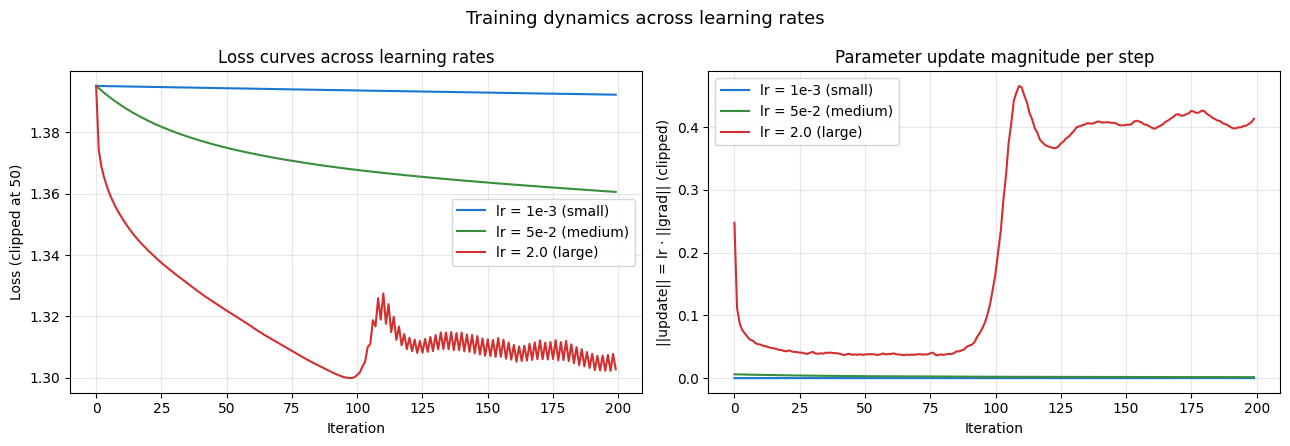


[ Observation summary ]
  lr = 1e-3 (small)       final loss ≈    1.392   tail std ≈   0.000
  lr = 5e-2 (medium)      final loss ≈    1.361   tail std ≈   0.001
  lr = 2.0 (large)        final loss ≈    1.303   tail std ≈   0.003

-> These numbers are observations for this specific setup (init, data, model).
   Update size depends on lr * grad magnitude; optimal lr varies with model/data.


In [25]:
# Learning rate 3종 비교: 같은 초기화로 학습, loss 곡선 관찰
np.random.seed(42)
N, D, H, C = 200, 2, 64, 4
X_exp = np.random.randn(N, D)
y_exp = np.random.randint(C, size=N)

def fresh_params():
    np.random.seed(0)
    return {
        'W1': np.random.randn(D, H) * 0.1,
        'b1': np.zeros(H),
        'W2': np.random.randn(H, C) * 0.1,
        'b2': np.zeros(C),
    }

lrs = [1e-3, 5e-2, 2.0]
colors = ['#1976D2', '#388E3C', '#D32F2F']
labels = ['lr = 1e-3 (small)', 'lr = 5e-2 (medium)', 'lr = 2.0 (large)']

histories = {}
update_histories = {}
for lr in lrs:
    params = fresh_params()
    losses, updates = [], []
    for it in range(200):
        loss, grads = two_layer_net(X_exp, params, y_exp, reg=1e-3)
        losses.append(loss)
        # update magnitude = lr * ||grad||
        step_norm = lr * np.sqrt(sum(np.sum(g**2) for g in grads.values()))
        updates.append(step_norm)
        for name in params:
            params[name] -= lr * grads[name]
    histories[lr] = losses
    update_histories[lr] = updates

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Loss curves
for lr, color, lbl in zip(lrs, colors, labels):
    losses = histories[lr]
    # clip for display if exploded
    losses_clip = np.clip(losses, None, 50)
    axes[0].plot(losses_clip, color=color, label=lbl, lw=1.5)
axes[0].set_xlabel('Iteration'); axes[0].set_ylabel('Loss (clipped at 50)')
axes[0].set_title('Loss curves across learning rates')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Update magnitude
for lr, color, lbl in zip(lrs, colors, labels):
    ups = update_histories[lr]
    ups_clip = np.clip(ups, None, 20)
    axes[1].plot(ups_clip, color=color, label=lbl, lw=1.5)
axes[1].set_xlabel('Iteration'); axes[1].set_ylabel('||update|| = lr · ||grad|| (clipped)')
axes[1].set_title('Parameter update magnitude per step')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Training dynamics across learning rates', fontsize=13)
plt.tight_layout(); plt.show()

# 텍스트 요약
print("\n[ Observation summary ]")
for lr, lbl in zip(lrs, labels):
    h = histories[lr]
    final = h[-1]
    # simple oscillation proxy: std of last 50 iters
    tail_std = float(np.std(h[-50:]))
    print(f"  {lbl:22s}  final loss ≈ {final:8.3f}   tail std ≈ {tail_std:7.3f}")
print("\n-> These numbers are observations for this specific setup (init, data, model).")
print("   Update size depends on lr * grad magnitude; optimal lr varies with model/data.")


## 정리

| 구현 항목 | Forward | Backward | 핵심 포인트 |
|-----------|---------|----------|------------|
| **Affine** | $XW + b$ | $dX=dout \cdot W^T$, $dW=X^T \cdot dout$ | reshape 주의, Multiplier Gate |
| **ReLU** | $\max(0, x)$ | $dout \cdot \mathbb{1}[x>0]$ | Gate: 양수만 통과, 음수는 차단 |
| **Softmax Loss** | $-\log(\text{softmax})$ | $(p - \text{one\_hot}) / N$ | 수치 안정성: max 빼기 |
| **2-Layer Net** | Affine→ReLU→Affine→Loss | 역순으로 gradient 전파 | cache로 중간값 재활용 |

### 핵심 교훈
1. **Gate Operations**: 모든 연산은 Adder/Multiplier/Fanout gate로 분해 가능
2. **Modular Design**: forward(cache) + backward(dout, cache) 패턴으로 어떤 레이어든 구현
3. **Gradient Checking**: 수치 미분 vs 해석적 미분 비교 → 구현 오류 검출의 필수 도구
4. **학습률의 역할**: 업데이트 크기는 `lr × gradient`로 결정되며, 같은 gradient라도 lr에 따라 loss 양상이 달라지는 경향을 관찰
